In [1]:
import pandas as pd
import numpy as np
import pastas as ps
import matplotlib.pyplot as plt

from pathlib import Path

ps.set_log_level("ERROR") # silence INFO spam

/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA = Path("/home/py/groundwater/data")

In [3]:
head_wide = pd.read_csv(DATA/'gown'/'combined_absval.csv', index_col=0, parse_dates=True).loc['2012':]

In [4]:
def get_head(code):
    h = head_wide[code].dropna()
    h.name = code
    return h

In [5]:
ECCC_DIR = DATA / 'eccc' / 'processed'
ACIS_DIR = DATA / 'acis' / 'processed'

banff = pd.read_csv(ECCC_DIR/'3050519_BANFF_CS.csv', usecols=[0, 7, 12], parse_dates=[0], index_col=0).loc['2012':'2024']

In [6]:
prec = banff.iloc[:,1]
temp = banff.iloc[:,0]

In [7]:
brab = pd.read_csv(DATA/'bow_valley/stream/Stage.Working@05BB001.20110101_corrected.csv', skiprows=14, usecols=[1, 2], parse_dates=[0], index_col=0).squeeze()
brab = brab+1376.388
brab = brab.resample('d').mean()

In [8]:
stage = brab.loc['2012':'2024']

In [9]:
import pyet

In [10]:
evap = pyet.oudin(temp, lat=0.892) # ~51.1°N in radians

In [11]:
def build_model(code, use_river=True, river_rfunc=None, rch_rfunc=None):
    ml = ps.Model(get_head(code), name=code)
    ps.RechargeModel(ml, prec, evap, recharge=ps.rch.FlexModel(snow=True),
                     rfunc=(rch_rfunc or ps.Gamma()), temp=temp, name="rch")
    if use_river:
        ps.StressModel(ml, stage - stage.mean(),        # <-- de-mean the stage
                       rfunc=(river_rfunc or ps.Exponential()),
                       name="river", settings="waterlevel")
    return ml

In [12]:
def solve_model(ml, tmin="2012", tmax="2024"):
    ml.solve(tmin=tmin, tmax=tmax, warmup=730, report=False)
    for p in ["rch_srmax", "rch_kv", "rch_k"]:      # weakly identified -> fix
        ml.set_parameter(p, vary=False)
    ps.ArNoiseModel(ml)                              # register noise model (step 2)
    ml.solve(tmin=tmin, tmax=tmax, warmup=730, initial=False, report=True)
    return ml

In [13]:
ml = build_model("0759", use_river=False)
ps.LinearTrend(ml, start="2012-01-01", end="2024-01-01", name="trend")

ml_0759_trend = solve_model(ml)

/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/pastas/decorators.py:120: FutureWarning: The start argument is deprecated and will not be available from Pastas version >= 2.4.0. Please use 'tstart' instead of 'start'.
  warn(message=msg, category=FutureWarning)
/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/pastas/decorators.py:120: FutureWarning: The end argument is deprecated and will not be available from Pastas version >= 2.4.0. Please use 'tend' instead of 'end'.
  warn(message=msg, category=FutureWarning)


Fit report 0759                      Fit Statistics
nfev     18                     EVP           59.01
nobs     4384                   R2             0.59
noise    True                   RMSE           0.50
tmin     2012-01-01 00:00:00    AICc      -21635.30
tmax     2024-01-01 00:00:00    BIC       -21584.25
freq     D                      Obj           15.70
freq_obs None                   ___                
warmup   730 days 00:00:00      Interp.          No

Parameters (8 optimized)
                    optimal        initial   vary
rch_A              4.235877       4.604460   True
rch_n              0.304230       0.472910   True
rch_a           3964.066461    1117.865635   True
rch_srmax       1000.000000    1000.000000  False
rch_lp             0.250000       0.250000  False
rch_ks           248.857867     999.999997   True
rch_gamma          5.000000       3.054202   True
rch_kv             0.250000       0.250000  False
rch_simax          2.000000       2.000000  False
rch_tt

In [14]:
ml_0760 = solve_model(build_model("0760", use_river=True)) # expect real river gain

ml_0759   = solve_model(build_model("0759", use_river=False)) # PRESSURE signal: recharge-only is primary
ml_0759_r = solve_model(build_model("0759", use_river=True)) # diagnostic: compare AICc + river IRF shape

ml_0364 = solve_model(build_model("0364", use_river=True)) # river likely dominant; test if recharge adds

Fit report 0760                      Fit Statistics
nfev     37                     EVP           87.02
nobs     4384                   R2             0.87
noise    True                   RMSE           0.26
tmin     2012-01-01 00:00:00    AICc      -33691.82
tmax     2024-01-01 00:00:00    BIC       -33634.39
freq     D                      Obj            1.00
freq_obs None                   ___                
warmup   730 days 00:00:00      Interp.          No

Parameters (9 optimized)
                 optimal      initial   vary
rch_A           1.044372     1.078598   True
rch_n           0.894859     1.079298   True
rch_a         682.547273   378.664252   True
rch_srmax      73.378287    73.378287  False
rch_lp          0.250000     0.250000  False
rch_ks        104.632509   181.942604   True
rch_gamma       3.652885     4.375410   True
rch_kv          1.926634     1.926634  False
rch_simax       2.000000     2.000000  False
rch_tt          0.000000     0.000000  False
rch_k      

In [15]:
print("recharge-only :", ml_0759.parameters.loc["rch_a", "optimal"])       # was 1075 d
print("with trend    :", ml_0759_trend.parameters.loc["rch_a", "optimal"])

recharge-only : 1232.245942171668
with trend    : 3964.0664609499145


-21636.737278961584 -> -21635.303360002014


<Axes: >

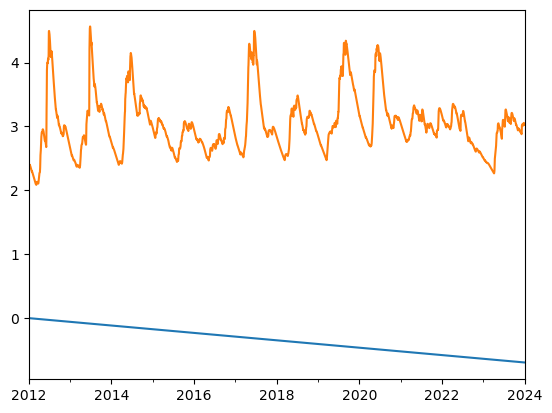

In [16]:
# 1. Did the fit actually improve, or did the trend just relabel variance?
print(ml_0759.stats.aicc(), "->", ml_0759_trend.stats.aicc())    # meaningful drop = trend earns its 2 params

# 2. Look at what the trend claims and whether recharge lost its ramp.
ml_0759_trend.get_contribution("trend").plot()   # a steady slope, or is it straightening the 2023 dip?
ml_0759_trend.get_contribution("rch").plot()      # freshet pulses now around a flat baseline?

/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/pastas/plotting/modelplots.py:346: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axd[con_key].set_ylim(ylims[con_key])
/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/IPython/core/events.py:96: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)


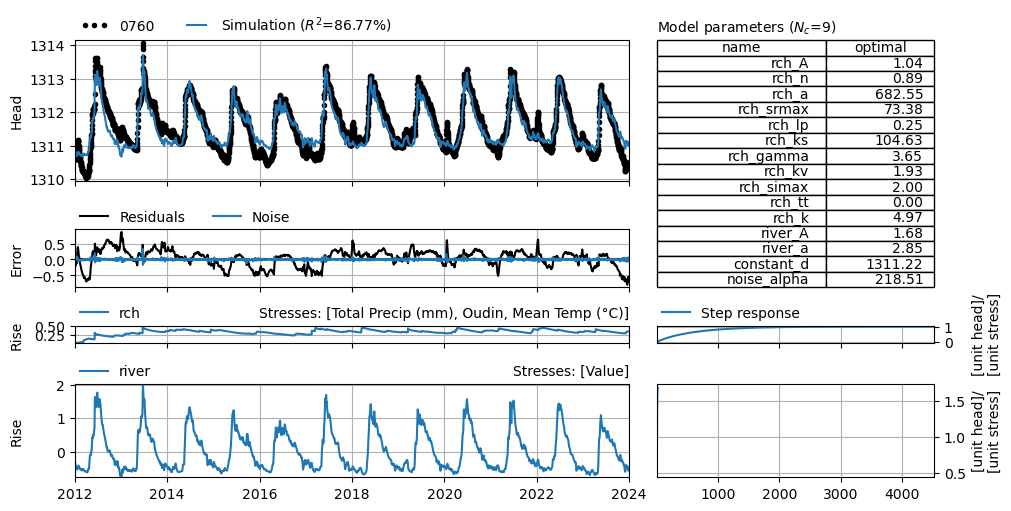

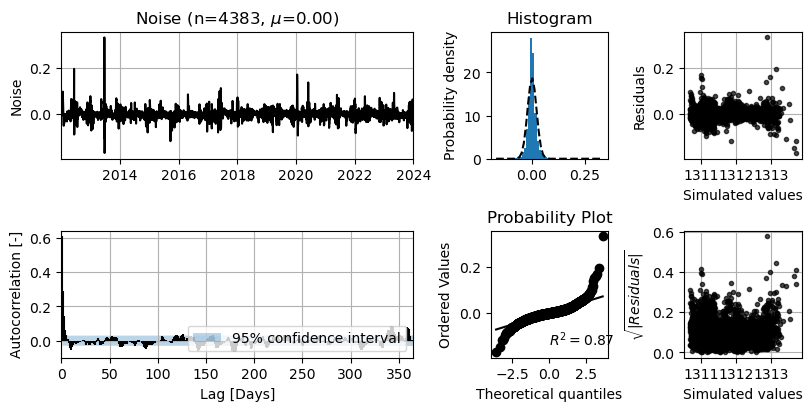

/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


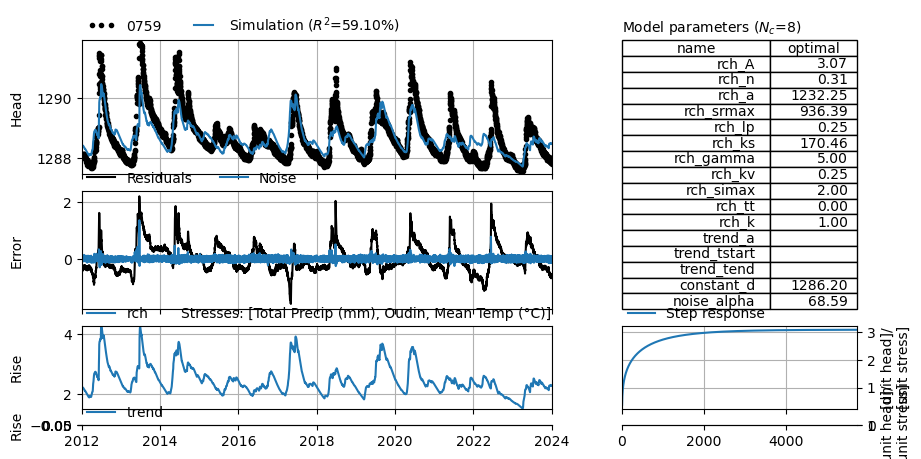

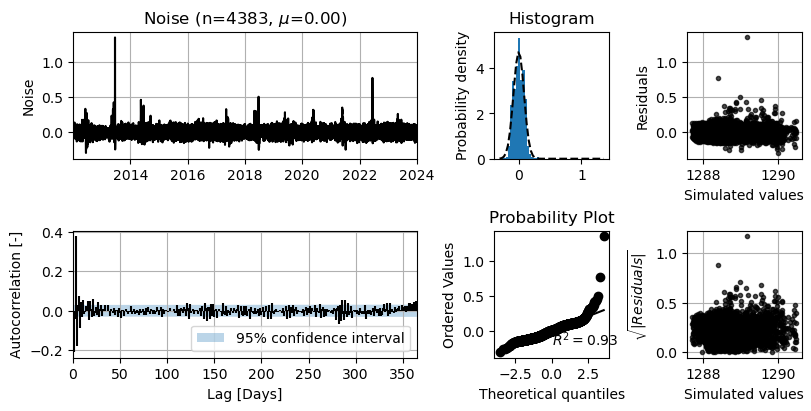

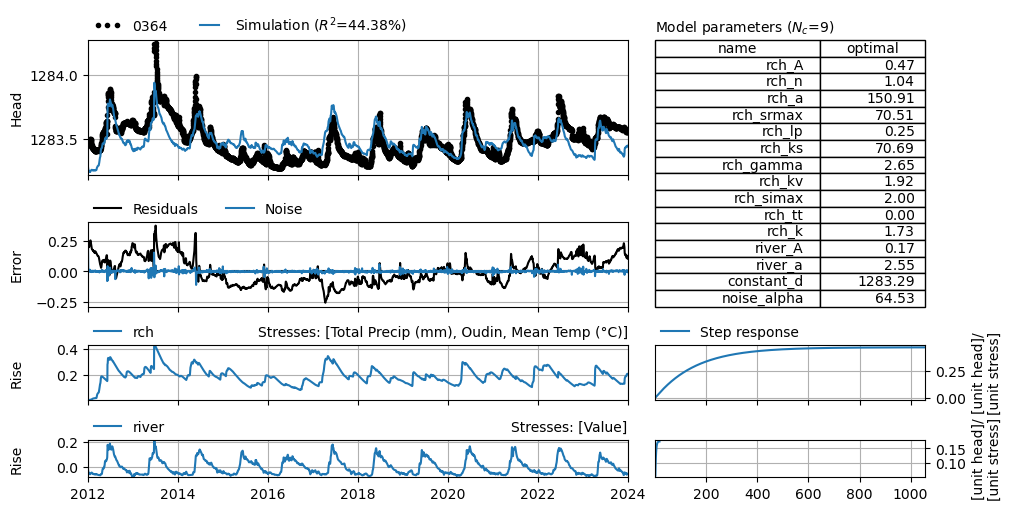

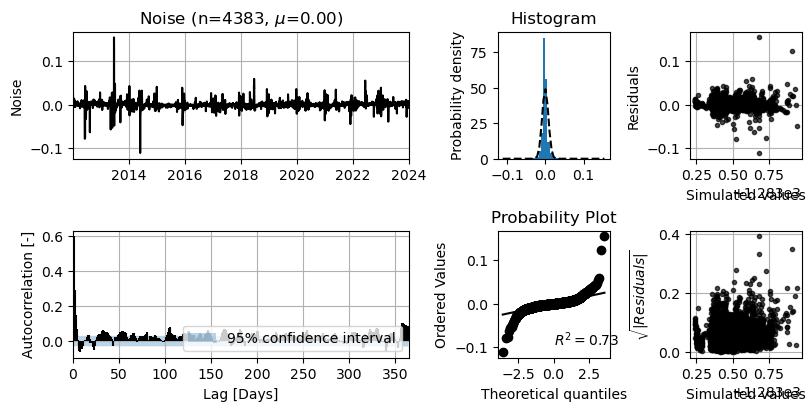

In [91]:
for ml in [ml_0760, ml_0759, ml_0364]:
    ml.plots.results(figsize=(10,5))
    ml.plots.diagnostics()      # PRIMARY adequacy check: innovations ACF must be ~white

def features(ml):
    f = {"evp": ml.stats.evp(), "rmse": ml.stats.rmse()}
    f["rch_gain"]   = ml.get_step_response("rch").iloc[-1]      # steady-state head per unit sustained recharge
    f["rch_tmax95"] = ml.get_response_tmax("rch", cutoff=0.95)   # recharge response time
    if "river" in ml.stressmodels:
        f["river_gain"]   = ml.get_step_response("river").iloc[-1]   # transmitted fraction of a stage change
        f["river_tmax95"] = ml.get_response_tmax("river", cutoff=0.95)
    return f

In [82]:
ml_0759_r.get_contribution("river").mean()

np.float64(0.00048502717250118246)

<Axes: title={'center': '760'}>

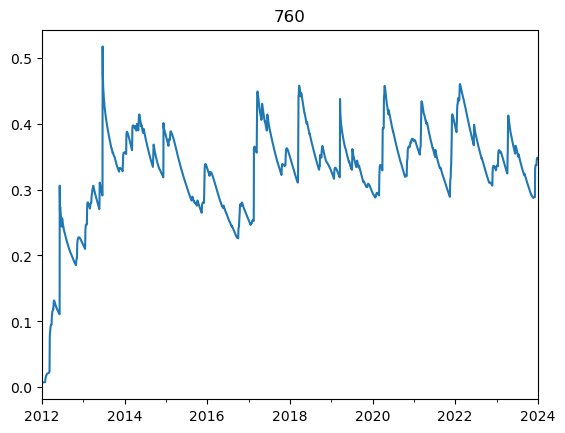

In [84]:
ml_0760.get_contribution("rch").plot(title='760')   # does it carry a multi-year ramp it shouldn't?

<Axes: title={'center': '759'}>

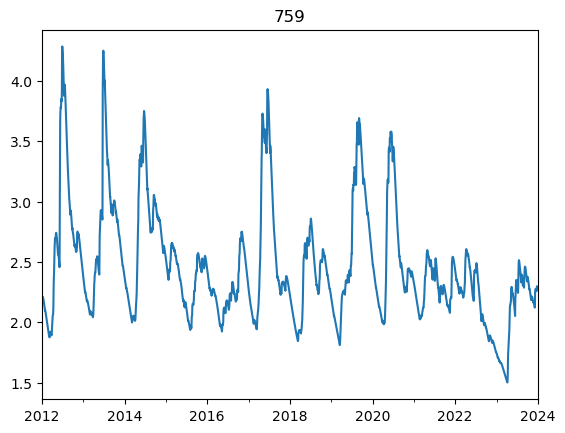

In [92]:
ml_0759.get_contribution("rch").plot(title='759')

[<Axes: label='series', title={'center': 'Noise (n=4383, $\\mu$=0.00)'}, ylabel='Noise'>,
 <Axes: label='hist', title={'center': 'Histogram'}, ylabel='Probability density'>,
 <Axes: label='het_res', xlabel='Simulated values', ylabel='Residuals'>,
 <Axes: label='acf', xlabel='Lag [Days]', ylabel='Autocorrelation [-]'>,
 <Axes: label='qq', title={'center': 'Probability Plot'}, xlabel='Theoretical quantiles', ylabel='Ordered Values'>,
 <Axes: label='het_sqrt', xlabel='Simulated values', ylabel='$\\sqrt{|Residuals|}$'>]

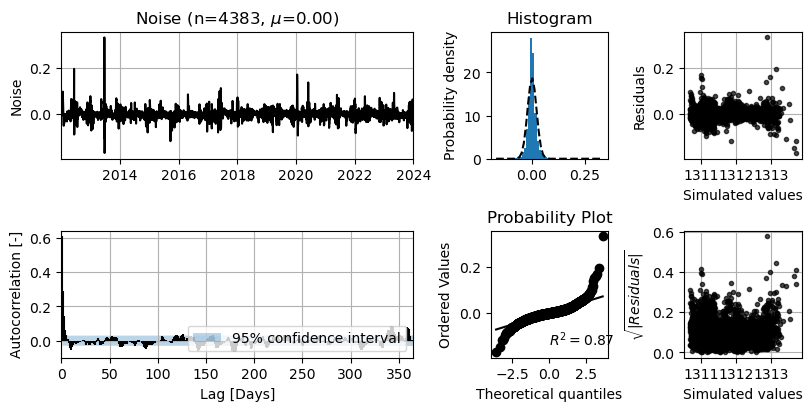

In [88]:
ml_0760.plots.diagnostics()

In [89]:
features(ml_0760)                                   # river_gain, river_tmax95, rch_tmax95, rch_gain
[c.var() for c in ml_0760.get_contributions()]      # variance split river vs recharge — a good cluster feature

[np.float64(0.005459680299946136), np.float64(0.3439532960576281)]

In [90]:
ps.LinearTrend(ml_0759, start="2012-01-01", end="2024-01-01", name="trend")

/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/pastas/decorators.py:120: FutureWarning: The start argument is deprecated and will not be available from Pastas version >= 2.4.0. Please use 'tstart' instead of 'start'.
  warn(message=msg, category=FutureWarning)
/home/py/mambaforge/envs/research-gwmo/lib/python3.14/site-packages/pastas/decorators.py:120: FutureWarning: The end argument is deprecated and will not be available from Pastas version >= 2.4.0. Please use 'tend' instead of 'end'.
  warn(message=msg, category=FutureWarning)
